# Tutorial 5d: Advanced Thin Film Applications

Consolidating color performance metrics, anti-reflective (AR) coating system design, and thin-film tolerance simulation.


In [1]:
import matplotlib.pyplot as plt
import optiland.backend as be
from optiland.materials import IdealMaterial, Material
from optiland.thin_film import SpectralAnalyzer, ThinFilmStack
from optiland.colorimetry.plotting import plot_cie_1931_chromaticity_diagram


## 1) Define the stack and wavelength grid

We use air as the incident medium, a TiO2 layer with variable thickness, and a silica (SiO2) substrate. The spectrum is sampled from 380 to 780 nm with a 5 nm step.

In [2]:
air = IdealMaterial(n=1.0)
sio2 = Material("SiO2", reference="Gao")
tio2 = Material("TiO2", reference="Zhukovsky")

stack = ThinFilmStack(incident_material=air, substrate_material=sio2)
stack.add_layer_nm(tio2, 0.0, name="TiO2")

analyzer = SpectralAnalyzer(stack)

max_thickness_nm = 250.0
wavelengths_nm = be.linspace(380.0, 780.0, 81)
thicknesses_nm = be.linspace(0.0, max_thickness_nm, 251)

## 2) Compute chromaticity for each thickness

We compute the reflected spectrum for each thickness, then extract CIE $x,y$ and an sRGB triplet for visualization. The spectrum is a normalized power quantity (R), which is sufficient for chromaticity.

In [3]:
x_path = []
y_path = []
colors = []

for thickness_nm in thicknesses_nm:
    stack.layers[0].thickness_um = float(thickness_nm) / 1000.0

    result = analyzer.analyze_color(
        wavelength_values=wavelengths_nm,
        wavelength_unit="nm",
        aoi=0.0,
        aoi_unit="deg",
        polarization="u",
        quantity="R",
        observer="2deg",
    )

    x, y, _ = result["xyY"]
    r, g, b = result["sRGB"]

    x_path.append(x)
    y_path.append(y)
    colors.append([r / 255.0, g / 255.0, b / 255.0])

## 3) Plot the chromaticity path on the CIE 1931 diagram

We plot the path and mark the start (0 nm) and end (250 nm) points.

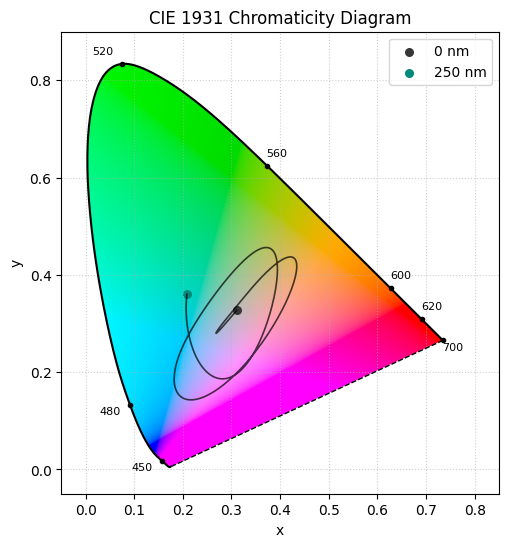

In [4]:
fig, ax = plot_cie_1931_chromaticity_diagram(color="fill")

ax.plot(x_path, y_path, color="black", linewidth=1.2, alpha=0.7)
ax.scatter(x_path[0], y_path[0], s=30, color=colors[0], label="0 nm")
ax.scatter(x_path[-1], y_path[-1], s=30, color=colors[-1], label="250 nm")
ax.legend()

plt.show()

## 4) Color bar versus thickness

This compact color bar summarizes the perceived reflected color as a function of TiO_2 thickness. We obtain the Michel-Levy chart.

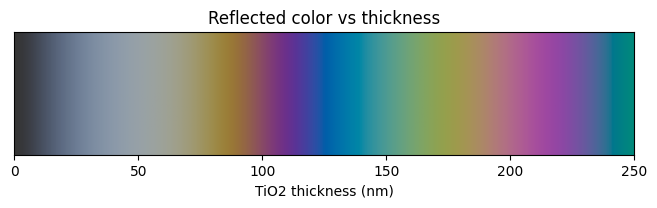

In [5]:
colors_array = be.asarray(colors)
colors_image = colors_array[None, :, :]

fig, ax = plt.subplots(figsize=(8, 1.6))
ax.imshow(
    colors_image,
    aspect="auto",
    extent=[float(thicknesses_nm[0]), float(thicknesses_nm[-1]), 0, 1],
)
ax.set_yticks([])
ax.set_xlabel("TiO2 thickness (nm)")
ax.set_title("Reflected color vs thickness")

plt.show()


---
## Part 2: Ar Coating System



## Introduction

Uncoated glass reflects about 4% of incident light per surface due to the refractive index mismatch between air ($n \approx 1$) and glass ($n \approx 1.5$). In multi-element optical systems, these losses accumulate and cause ghost images.

This tutorial demonstrates:
1.  **Baseline Analysis**: The reflection of a bare glass surface (Fresnel reflection).
2.  **BBAR Design**: Creating a 4-layer Anti-Reflective coating using $MgF_2$ and $TiO_2$.
3.  **Performance Comparison**: Visually and numerically comparing the coated vs. uncoated surface.
4.  **Angular Stability**: Evaluating performance at oblique angles of incidence ($0^\circ, 30^\circ, 60^\circ$).

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from optiland import optic
from optiland.materials import Material, IdealMaterial
from optiland.thin_film import ThinFilmStack
from optiland.coatings import ThinFilmCoating, FresnelCoating

## 1. Materials & Baseline Setup

We define the materials and the reference wavelength ($\lambda = 550$ nm).

In [6]:
# Define Materials
air = IdealMaterial(n=1.0)
glass = Material("N-BK7", reference="SCHOTT")
mgf2 = Material("MgF2", reference="Li")    # Low Index (~1.38)
tio2 = Material("TiO2", reference="Siefke") # High Index (~2.5)

# Setup wavelength range (Visible Spectrum)
wavelengths = np.linspace(0.45, 0.7, 301) # 450-700 nm in µm

# Baseline: Uncoated Glass (Fresnel Reflection)
# We use FresnelCoating to simulate the bare interface
bare_surface = FresnelCoating(air, glass)

## 2. Design the BBAR Stack

We implement a 4-layer BBAR design (LHLH structure).
Crucially, the first layer facing air must be the Low Index material to avoid large reflections.

**Stack Recipe (Air $\rightarrow$ Glass):**
1.  **MgF2** (94 nm) - Low Index (Outer Layer)
2.  **TiO2** (117 nm) - High Index
3.  **MgF2** (38 nm) - Low Index (Thin)
4.  **TiO2** (14 nm) - High Index (Inner Matching Layer)

This structure is optimized to suppress reflection across the visible spectrum (400-700nm).

In [7]:
# Create the Stack
bbar_stack = ThinFilmStack(incident_material=air, substrate_material=glass)

# Add layers (incident -> substrate)
# Start with Low Index (MgF2) facing Air to minimize first surface reflection.
# Thicknesses (um): ~94nm, ~117nm, ~38nm, ~14nm
# This is an optimized structure for 400-700nm.
bbar_stack.add_layer(mgf2, 0.094, "L1 (Outer)")
bbar_stack.add_layer(tio2, 0.117, "H1")
bbar_stack.add_layer(mgf2, 0.038, "L2")
bbar_stack.add_layer(tio2, 0.014, "H2 (Inner)")

# Create the Coating Object
bbar_coating = ThinFilmCoating(air, glass, bbar_stack)

# Inspect the design
print(bbar_stack)

ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. MgF2 (94.0 nm)
  2. TiO2 (117.0 nm)
  3. MgF2 (38.0 nm)
  4. TiO2 (14.0 nm)
---------------------
Total Thickness: 263.0 nm


## 3. Spectral Performance Analysis

We compare the Reflectance ($R$) of the BBAR coating against the bare glass baseline at normal incidence ($0^\circ$).

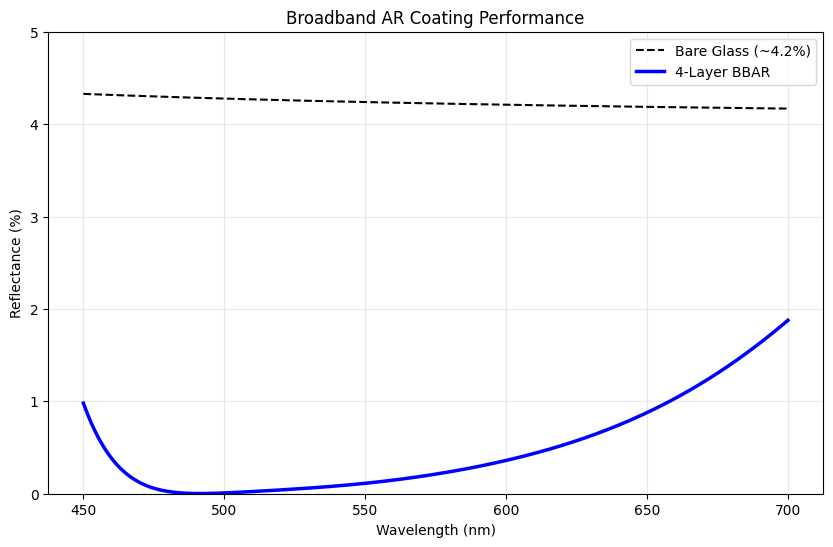

Average Reflectance (400-700nm): 0.48%


In [8]:
# Compute Reflectance for BBAR
R_bbar = bbar_stack.compute_rtRTA(wavelengths, aoi_rad=0.0, polarization="u")["R"]

# Compute Reflectance for Bare Glass
# We calculate theoretical Fresnel reflection for comparison
n_glass = glass.n(wavelengths)
R_glass = ((1.0 - n_glass) / (1.0 + n_glass))**2

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(wavelengths * 1000, R_glass * 100, 'k--', linewidth=1.5, label="Bare Glass (~4.2%)")
plt.plot(wavelengths * 1000, R_bbar * 100, 'b-', linewidth=2.5, label="4-Layer BBAR")

plt.title("Broadband AR Coating Performance")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 5)
plt.show()

avg_R_bbar = np.mean(R_bbar) * 100
print(f"Average Reflectance (400-700nm): {avg_R_bbar:.2f}%")

## 4. System Transmission Comparison: BBAR vs Fresnel

In this section, we compare the total transmission of the lens system coated with our custom BBAR stack versus a standard Fresnel (uncoated) system. We will visualize the pupil transmission map for both cases.

In [9]:
from optiland.rays import PolarizationState

class CoatedDoublet(optic.Optic):
    def __init__(self, coating=None):
        super().__init__()

        self.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
        self.surfaces.add(
            index=1,
            radius=29.32908,
            thickness=0.7,
            material="N-BK7",
            is_stop=True,
            coating=coating,
        )
        self.surfaces.add(index=2, radius=-20.06842, thickness=0.032, coating=coating)
        self.surfaces.add(
            index=3,
            radius=-20.08770,
            thickness=0.5780,
            material=("SF2", "schott"),
            coating=coating,
        )
        self.surfaces.add(index=4, radius=-66.54774, thickness=47.3562, coating=coating)
        self.surfaces.add(index=5)

        self.set_aperture(aperture_type="imageFNO", value=8.0)

        self.fields.set_type(field_type="angle")
        self.fields.add(y=0.0)
        self.fields.add(y=0.7)
        self.fields.add(y=1.0)

        self.wavelengths.add(value=0.4861)
        self.wavelengths.add(value=0.5876, is_primary=True)
        self.wavelengths.add(value=0.6563)

        self.update_paraxial()
        self.image_solve()

        # Set Polarization (Required for ThinFilmCoating)
        state = PolarizationState(is_polarized=False)
        self.set_polarization(state)

# 1. System with BBAR Coating
lens_bbar = CoatedDoublet(coating=bbar_coating)
rays_bbar = lens_bbar.trace(Hx=0, Hy=0, wavelength=0.55, num_rays=256, distribution="uniform")
intensity_bbar = rays_bbar.i

# 2. System with Standard Fresnel Surface (Air/Glass Refraction)
# We use a FresnelCoating to simulate the standard reflection loss at each interface (~4%)
fresnel_coating = FresnelCoating(air, glass)
lens_fresnel = CoatedDoublet(coating=fresnel_coating)
rays_fresnel = lens_fresnel.trace(Hx=0, Hy=0, wavelength=0.55, num_rays=256, distribution="uniform")
intensity_fresnel = rays_fresnel.i

print(f"Average Transmission (BBAR Coated): {np.mean(intensity_bbar):.4f}")
print(f"Average Transmission (Fresnel Uncoated): {np.mean(intensity_fresnel):.4f}")
print(f"Improvement: {(np.mean(intensity_bbar) - np.mean(intensity_fresnel)) / np.mean(intensity_fresnel) * 100:.1f}%")

Average Transmission (BBAR Coated): 0.9948
Average Transmission (Fresnel Uncoated): 0.8087
Improvement: 23.0%


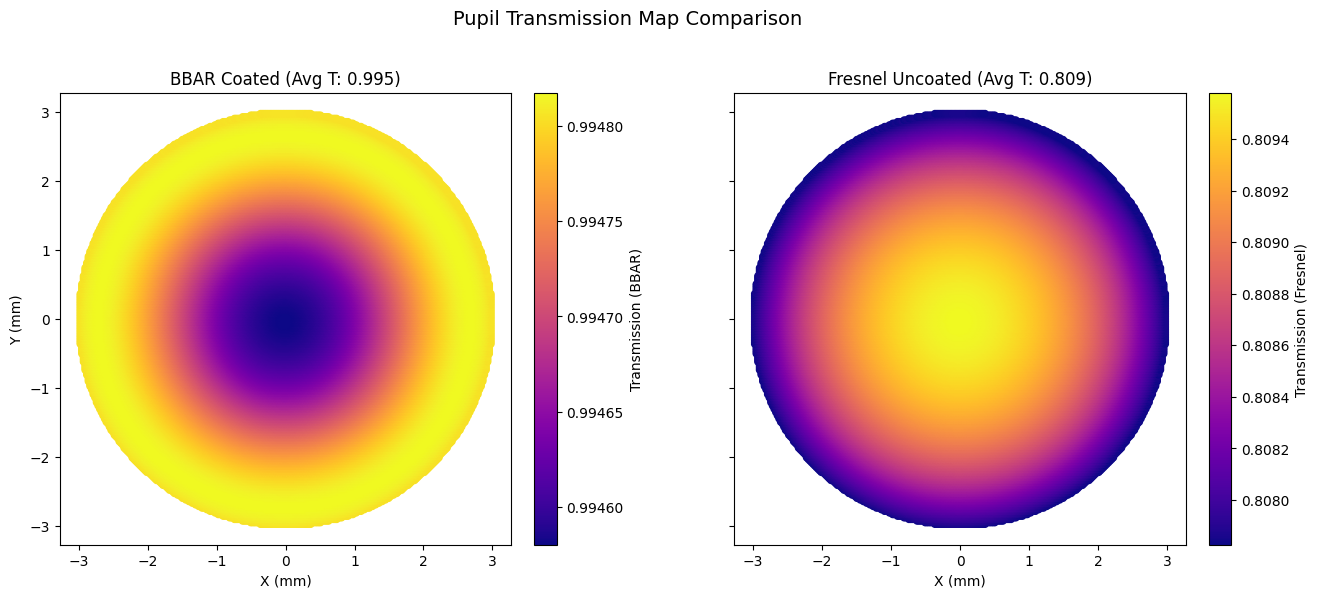

In [14]:
# Get pupil coordinates (Stop is at surface 1)
x_stop_bbar = lens_bbar.surfaces.x[1, :]
y_stop_bbar = lens_bbar.surfaces.y[1, :]

x_stop_fresnel = lens_fresnel.surfaces.x[1, :]
y_stop_fresnel = lens_fresnel.surfaces.y[1, :]

# Comparative visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

# Plot BBAR coated (own scale + own colorbar)
sc1 = axes[0].scatter(
    x_stop_bbar,
    y_stop_bbar,
    c=intensity_bbar,
    s=20,
    cmap="plasma",
    vmin=np.min(intensity_bbar),
    vmax=np.max(intensity_bbar),
)
axes[0].set_title(f"BBAR Coated (Avg T: {np.mean(intensity_bbar):.3f})")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("X (mm)")
axes[0].set_ylabel("Y (mm)")
cbar1 = fig.colorbar(sc1, ax=axes[0], orientation="vertical", fraction=0.046, pad=0.04)
cbar1.set_label("Transmission (BBAR)")

# Plot Fresnel uncoated (own scale + own colorbar)
sc2 = axes[1].scatter(
    x_stop_fresnel,
    y_stop_fresnel,
    c=intensity_fresnel,
    s=20,
    cmap="plasma",
    vmin=np.min(intensity_fresnel),
    vmax=np.max(intensity_fresnel),
)
axes[1].set_title(f"Fresnel Uncoated (Avg T: {np.mean(intensity_fresnel):.3f})")
axes[1].set_aspect("equal", adjustable="box")
axes[1].set_xlabel("X (mm)")
cbar2 = fig.colorbar(sc2, ax=axes[1], orientation="vertical", fraction=0.046, pad=0.04)
cbar2.set_label("Transmission (Fresnel)")

plt.suptitle("Pupil Transmission Map Comparison", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


---
## Part 3: Thin Film Tolerance Analysis



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from optiland.materials import Material, IdealMaterial
from optiland.thin_film import ThinFilmStack
from optiland.thin_film.optimization.operand.thin_film import ThinFilmOperand
from optiland.thin_film.tolerancing import (
    ThinFilmTolerancing,
    ThinFilmSensitivityAnalysis,
    ThinFilmMonteCarlo,
)
from optiland.tolerancing.perturbation import RangeSampler, DistributionSampler

## 1. Nominal design: 7-layer broadband AR on N-BK7

This is the optimized design from Tutorial 6h (needle synthesis). It uses alternating MgF2/Al2O3 layers to achieve R < 1% across 420–680 nm.

In [2]:
air = IdealMaterial(n=1.0)
nbk7 = Material("N-BK7")
mgf2 = Material("MgF2", reference="Dodge-o")
al2o3 = Material("Al2O3", reference="Malitson")

# 7-layer design from needle synthesis (Tutorial 6h)
stack = ThinFilmStack(incident_material=air, substrate_material=nbk7)
stack.add_layer_nm(mgf2, 94.6, name="MgF2")
stack.add_layer_nm(al2o3, 319.7, name="Al2O3")
stack.add_layer_nm(mgf2, 17.7, name="MgF2")
stack.add_layer_nm(al2o3, 196.1, name="Al2O3")
stack.add_layer_nm(mgf2, 26.3, name="MgF2")
stack.add_layer_nm(al2o3, 170.9, name="Al2O3")
stack.add_layer_nm(mgf2, 190.4, name="MgF2")
print(stack)

ThinFilmStack Summary
---------------------
Incident:  IdealMaterial
Substrate: N-BK7
Layers:
  1. MgF2 (94.6 nm)
  2. Al2O3 (319.7 nm)
  3. MgF2 (17.7 nm)
  4. Al2O3 (196.1 nm)
  5. MgF2 (26.3 nm)
  6. Al2O3 (170.9 nm)
  7. MgF2 (190.4 nm)
---------------------
Total Thickness: 1015.7 nm


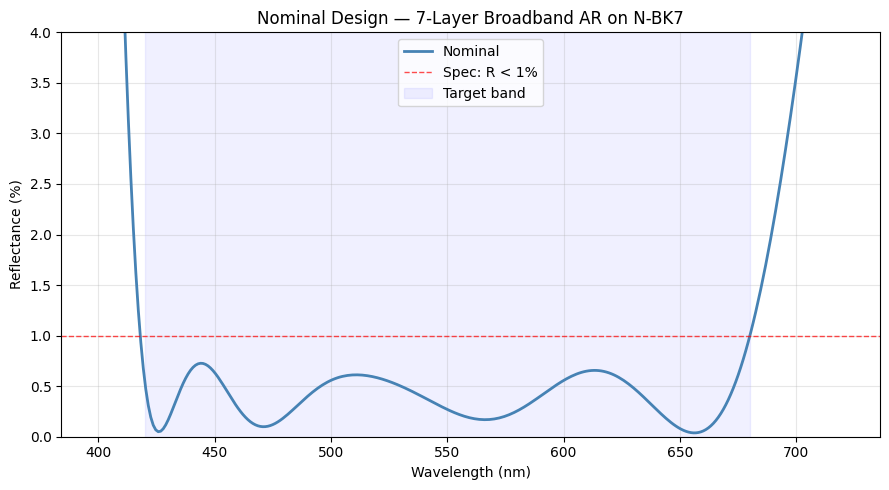

In [3]:
wl_plot = np.linspace(400, 720, 300)
R_nominal = np.array([ThinFilmOperand.reflectance(stack, wl) for wl in wl_plot])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_plot, R_nominal * 100, "-", color="steelblue", linewidth=2, label="Nominal")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Spec: R < 1%")
ax.axvspan(420, 680, alpha=0.06, color="blue", label="Target band")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Nominal Design — 7-Layer Broadband AR on N-BK7")
ax.set_ylim(0, 4)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout();

## 2. Sensitivity Analysis

We perturb each layer thickness individually by ±3% (typical for ion-beam sputtering) and observe how reflectance at blue (450 nm), green (550 nm), and red (650 nm) responds. This reveals which of the 7 layers are most critical to control.

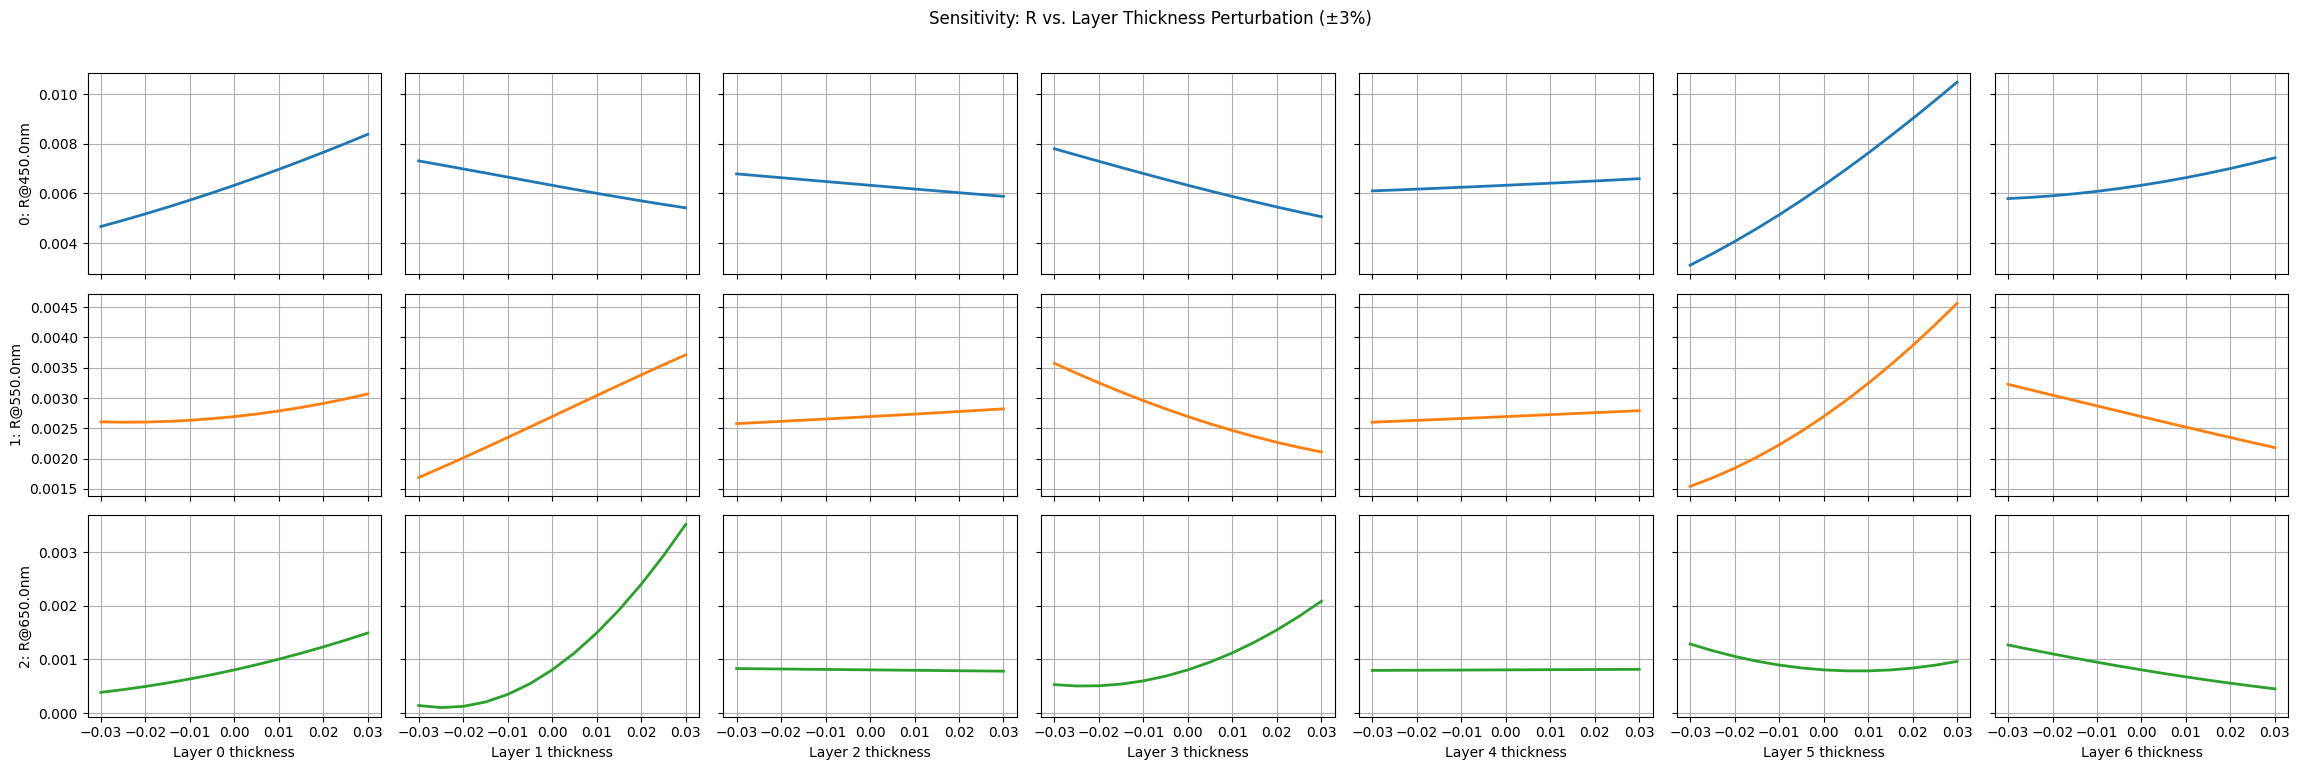

In [4]:
tol = ThinFilmTolerancing(stack)

# Operands: reflectance at three key wavelengths
tol.add_operand("R", 450.0)
tol.add_operand("R", 550.0)
tol.add_operand("R", 650.0)

# ±3% thickness perturbation on each of the 7 layers
for i in range(7):
    tol.add_perturbation(i, "thickness", RangeSampler(-0.03, 0.03, 13))

sa = ThinFilmSensitivityAnalysis(tol)
sa.run()

fig, axes = sa.view()
fig.suptitle("Sensitivity: R vs. Layer Thickness Perturbation (±3%)", y=1.02)
fig.tight_layout();

In [5]:
# Identify which layers have the steepest sensitivity slopes
df_sa = sa.get_results()
operand_cols = [c for c in df_sa.columns if c.startswith("0:") or c.startswith("1:") or c.startswith("2:")]

print("Sensitivity range (max - min reflectance) per layer:")
for ptype in df_sa["perturbation_type"].unique():
    mask = df_sa["perturbation_type"] == ptype
    ranges = df_sa.loc[mask, operand_cols].max() - df_sa.loc[mask, operand_cols].min()
    worst = ranges.max()
    print(f"  {ptype}: max ΔR = {worst*100:.3f}%")

Sensitivity range (max - min reflectance) per layer:
  Layer 0 thickness: max ΔR = 0.371%
  Layer 1 thickness: max ΔR = 0.341%
  Layer 2 thickness: max ΔR = 0.091%
  Layer 3 thickness: max ΔR = 0.274%
  Layer 4 thickness: max ΔR = 0.049%
  Layer 5 thickness: max ΔR = 0.737%
  Layer 6 thickness: max ΔR = 0.164%


## 3. Monte Carlo Analysis

We apply normally-distributed thickness errors (2% std, relative) to all 7 layers simultaneously over 500 trials. This models realistic sputtering variability.

In [6]:
tol_mc = ThinFilmTolerancing(stack)

# Operands: reflectance at 5 wavelengths across the band
for wl in [430.0, 480.0, 550.0, 620.0, 670.0]:
    tol_mc.add_operand("R", wl)

# 2% std thickness perturbation on all 7 layers
for i in range(7):
    tol_mc.add_perturbation(
        i, "thickness",
        DistributionSampler("normal", seed=100 + i, loc=0.0, scale=0.02),
    )

mc = ThinFilmMonteCarlo(tol_mc)
mc.run(num_iterations=500)
print(f"Monte Carlo complete: {len(mc.get_results())} trials")

Monte Carlo complete: 500 trials


### 3a. Reflectance distributions at key wavelengths

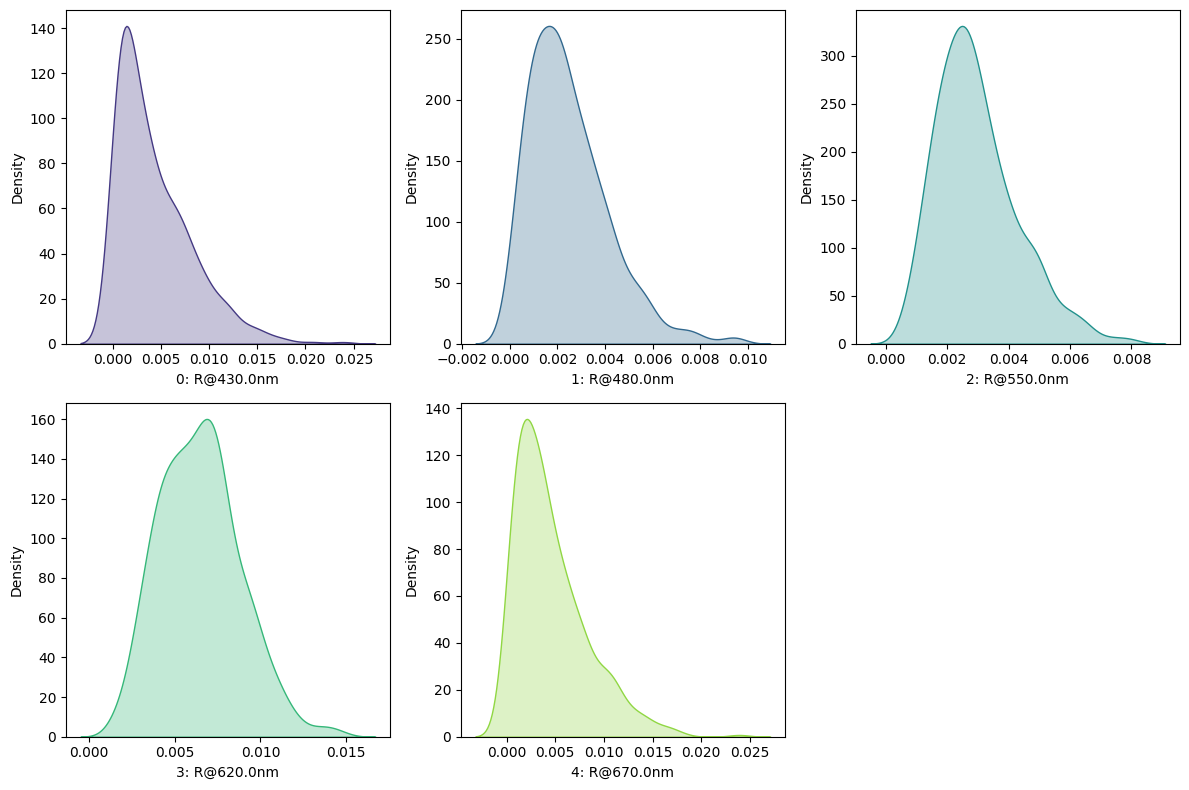

In [7]:
fig, axes = mc.view_histogram(kde=True)

### 3b. Cumulative distribution — yield analysis

Read off yield from the CDF: e.g., what fraction of parts will have R < 1% at each wavelength?

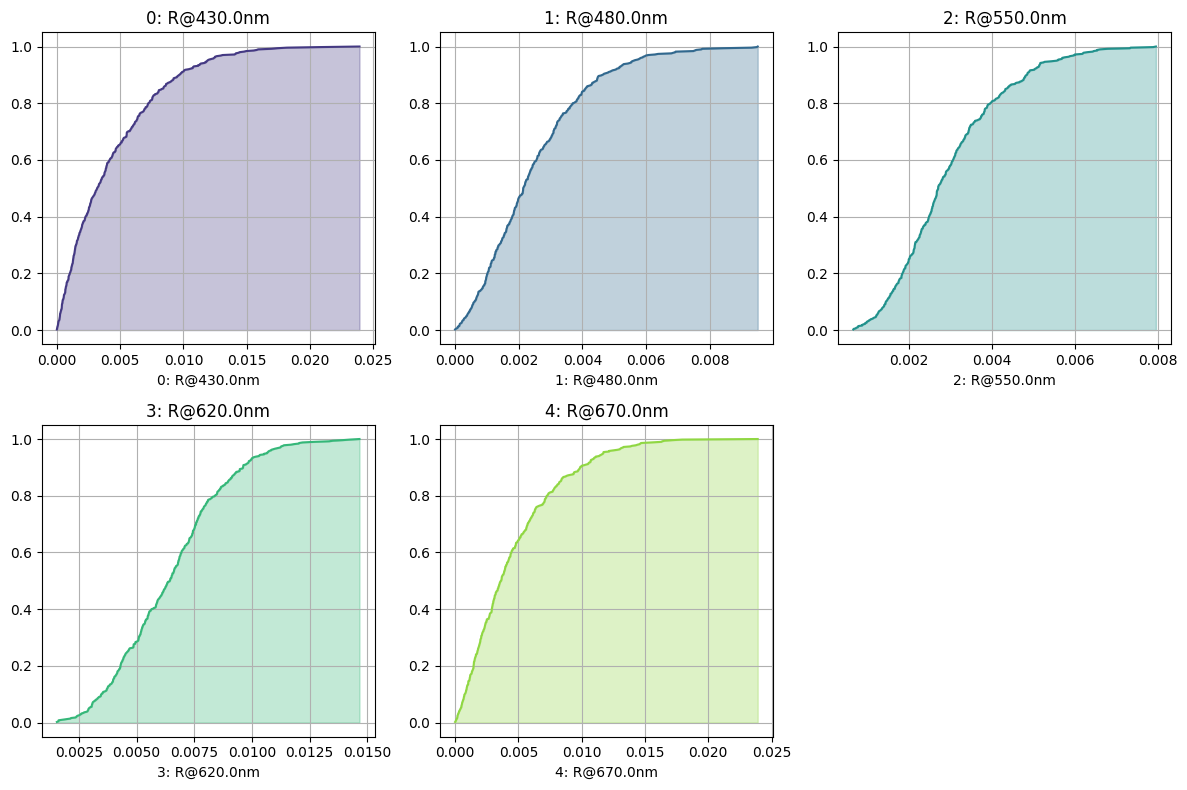

In [8]:
fig, axes = mc.view_cdf()

### 3c. Spectral tolerance band

This is the most informative plot: we compute the **full reflectance spectrum** for 200 random thickness perturbations. The shaded band shows the min/max envelope — the range of spectral performance you should expect in production.

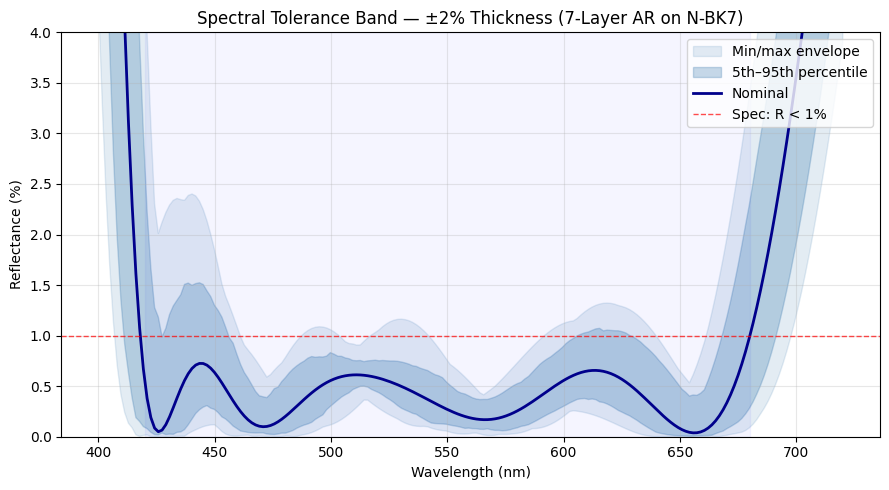

In [9]:
# Store nominal thicknesses
nominal_thicknesses = [layer.thickness_um for layer in stack.layers]
rng = np.random.default_rng(42)

wl_band = np.linspace(400, 720, 200)
n_trials = 200
all_R = np.zeros((n_trials, len(wl_band)))

# Compute nominal spectrum on this grid
R_nom_band = np.array([ThinFilmOperand.reflectance(stack, wl) for wl in wl_band])

for trial in range(n_trials):
    # Apply random ±2% thickness perturbations to all layers
    for i, nom in enumerate(nominal_thicknesses):
        delta = rng.normal(0.0, 0.02)
        stack.layers[i].thickness_um = nom * (1.0 + delta)

    # Compute full spectrum
    all_R[trial] = [ThinFilmOperand.reflectance(stack, wl) for wl in wl_band]

    # Reset to nominal
    for i, nom in enumerate(nominal_thicknesses):
        stack.layers[i].thickness_um = nom

R_min = all_R.min(axis=0)
R_max = all_R.max(axis=0)
R_p05 = np.percentile(all_R, 5, axis=0)
R_p95 = np.percentile(all_R, 95, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(wl_band, R_min * 100, R_max * 100, alpha=0.15, color="steelblue",
                label="Min/max envelope")
ax.fill_between(wl_band, R_p05 * 100, R_p95 * 100, alpha=0.3, color="steelblue",
                label="5th–95th percentile")
ax.plot(wl_band, R_nom_band * 100, "-", color="darkblue", linewidth=2, label="Nominal")
ax.axhline(1.0, color="red", linestyle="--", linewidth=1, alpha=0.7, label="Spec: R < 1%")
ax.axvspan(420, 680, alpha=0.04, color="blue")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Reflectance (%)")
ax.set_title("Spectral Tolerance Band — ±2% Thickness (7-Layer AR on N-BK7)")
ax.set_ylim(0, 4)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
fig.tight_layout();

### 3d. Summary statistics and yield

In [10]:
df = mc.get_results()
operand_cols = [c for c in df.columns if "R@" in c]

print("Reflectance statistics under ±2% thickness tolerance (500 trials):\n")
print(df[operand_cols].describe().round(6))

# Yield analysis: fraction of parts meeting R < 1% at each wavelength
print("\nYield (fraction with R < 1%):")
for col in operand_cols:
    yield_pct = (df[col] < 0.01).mean() * 100
    print(f"  {col}: {yield_pct:.1f}%")

Reflectance statistics under ±2% thickness tolerance (500 trials):

       0: R@430.0nm  1: R@480.0nm  2: R@550.0nm  3: R@620.0nm  4: R@670.0nm
count    500.000000    500.000000    500.000000    500.000000    500.000000
mean       0.004305      0.002464      0.002961      0.006467      0.004579
std        0.003873      0.001676      0.001325      0.002358      0.003699
min        0.000002      0.000000      0.000652      0.001547      0.000004
25%        0.001296      0.001213      0.002004      0.004630      0.001767
50%        0.003191      0.002141      0.002699      0.006449      0.003648
75%        0.006387      0.003319      0.003732      0.007849      0.006315
max        0.023909      0.009502      0.007952      0.014665      0.023904

Yield (fraction with R < 1%):
  0: R@430.0nm: 91.0%
  1: R@480.0nm: 100.0%
  2: R@550.0nm: 100.0%
  3: R@620.0nm: 93.2%
  4: R@670.0nm: 90.2%


## Interpretation

- The **sensitivity analysis** reveals which layers dominate the error budget — steep curves mean tight thickness control is needed on that layer.
- The **spectral tolerance band** shows the full range of reflectance spectra under manufacturing variations. Where the max envelope crosses the 1% spec line indicates the wavelengths most at risk.
- The **yield analysis** quantifies what fraction of manufactured parts will meet spec at each wavelength — this directly informs go/no-go decisions for production tolerances.
- For this 7-layer AR coating, ±2% thickness control (achievable with modern ion-beam sputtering) keeps reflectance well within spec across most of the band.